# Fig: Path length: Infotaxis vs MAP comparison: pmax_th=0.95

Reference: 
- `20251027_infotaxis_vs_MP_cmp_random_target_across_pm_hist_2conditions_1e-5.ipynb`
- `20251214_fig_infotaxis_MAP_cmp.ipynb`

In [1]:
from pathlib import Path

import pandas as pd

import seaborn as sns

In [2]:
from plot_utils import bar_violinplot_path_length
from simulation_data_prep import get_success_fname

In [3]:
# Set path
path_data = Path("/Volumes/ssd_2tb_1/infotaxis_simu_2026")

path_fig = Path("../figs_paper_2026")

Samples: left:  989    right:  514
Mean:    left: 42.833  right: 49.784
Median:  left: 37.000  right: 46.000

MWU test
 - different: 0.00093
 - less:      0.00046
 - greater:   0.99954
--------------------------------------------
Samples: left:  991    right:  545
Mean:    left: 45.306  right: 52.552
Median:  left: 40.000  right: 48.000

MWU test
 - different: 0.00014
 - less:      0.00007
 - greater:   0.99993
--------------------------------------------
Samples: left:  971    right:  534
Mean:    left: 48.697  right: 54.434
Median:  left: 43.000  right: 46.500

MWU test
 - different: 0.04184
 - less:      0.02092
 - greater:   0.97909
--------------------------------------------
Samples: left:  976    right:  501
Mean:    left: 56.272  right: 62.725
Median:  left: 47.000  right: 52.000

MWU test
 - different: 0.17268
 - less:      0.08634
 - greater:   0.91368
--------------------------------------------


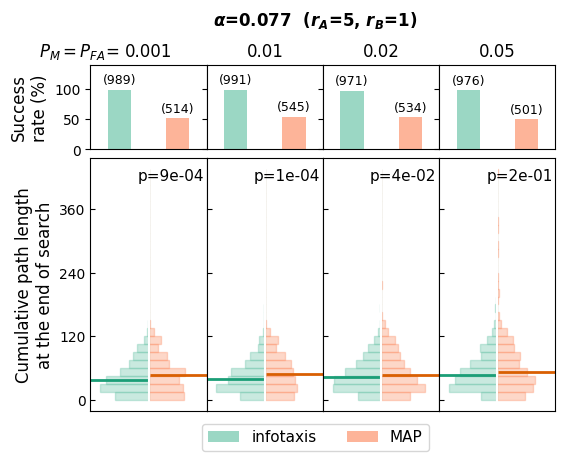

Samples: left:  977    right:  339
Mean:    left: 28.538  right: 29.422
Median:  left: 26.000  right: 29.000

MWU test
 - different: 0.73686
 - less:      0.36843
 - greater:   0.63163
--------------------------------------------
Samples: left:  974    right:  303
Mean:    left: 35.698  right: 32.954
Median:  left: 32.000  right: 30.000

MWU test
 - different: 0.01829
 - less:      0.99086
 - greater:   0.00915
--------------------------------------------
Samples: left:  969    right:  300
Mean:    left: 42.736  right: 37.533
Median:  left: 39.000  right: 35.000

MWU test
 - different: 0.00002
 - less:      0.99999
 - greater:   0.00001
--------------------------------------------
Samples: left:  959    right:  298
Mean:    left: 80.444  right: 50.842
Median:  left: 74.000  right: 46.000

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


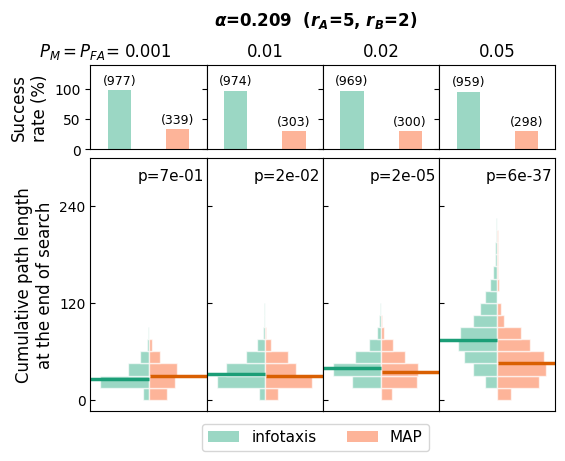

Samples: left:  986    right:  524
Mean:    left: 253.143  right: 306.786
Median:  left: 226.000  right: 266.000

MWU test
 - different: 0.00009
 - less:      0.00004
 - greater:   0.99996
--------------------------------------------
Samples: left:  985    right:  535
Mean:    left: 261.627  right: 313.512
Median:  left: 239.000  right: 284.000

MWU test
 - different: 0.00011
 - less:      0.00005
 - greater:   0.99995
--------------------------------------------
Samples: left:  968    right:  520
Mean:    left: 267.586  right: 331.904
Median:  left: 230.000  right: 293.000

MWU test
 - different: 0.00001
 - less:      0.00000
 - greater:   1.00000
--------------------------------------------
Samples: left:  967    right:  510
Mean:    left: 326.054  right: 352.973
Median:  left: 265.000  right: 274.500

MWU test
 - different: 0.72084
 - less:      0.36042
 - greater:   0.63963
--------------------------------------------


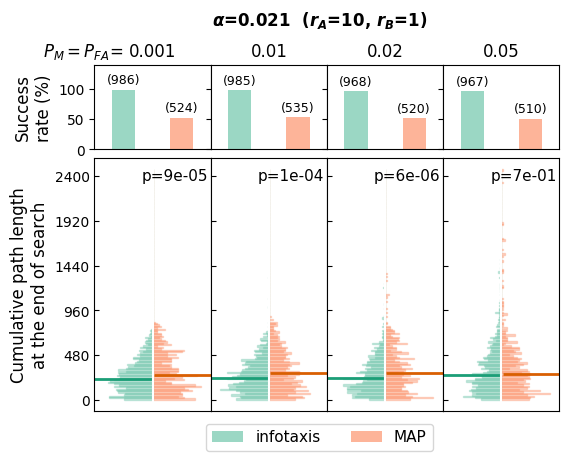

Samples: left:  980    right:  313
Mean:    left: 108.593  right: 130.326
Median:  left: 94.500  right: 119.000

MWU test
 - different: 0.00736
 - less:      0.00368
 - greater:   0.99632
--------------------------------------------
Samples: left:  966    right:  332
Mean:    left: 121.587  right: 138.840
Median:  left: 103.000  right: 121.500

MWU test
 - different: 0.01549
 - less:      0.00774
 - greater:   0.99226
--------------------------------------------
Samples: left:  968    right:  306
Mean:    left: 137.285  right: 144.346
Median:  left: 117.000  right: 128.000

MWU test
 - different: 0.28668
 - less:      0.14334
 - greater:   0.85670
--------------------------------------------
Samples: left:  961    right:  244
Mean:    left: 224.341  right: 154.754
Median:  left: 225.000  right: 125.500

MWU test
 - different: 0.00000
 - less:      1.00000
 - greater:   0.00000
--------------------------------------------


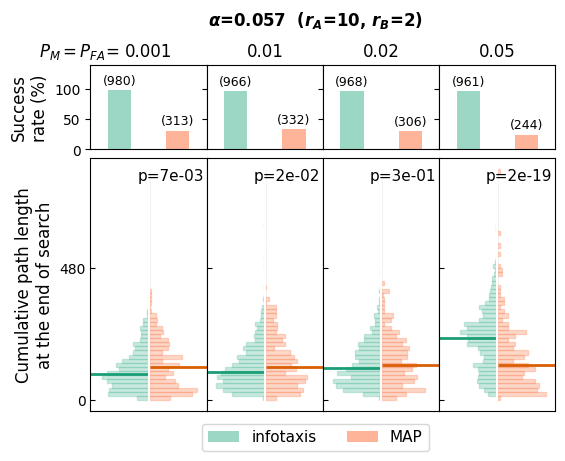

In [4]:
cr_all = [5, 10]
br_all = [1, 2]
pm_all = [0.001, 0.01, 0.02, 0.05]

for cr in cr_all:
    for br in br_all:

        path_left = path_data / "20260530_infotaxis_match_summary_compiled_pmax095_pmaxDiff1e-5"
        path_right = path_data / "20260530_MAP_match_summary_compiled_pmax095_pmaxDiff1e-5"
        pmax_th = 0.95
        pmax_diff_th=1e-5

        df_x_all = []
        df_y_all = []
        for pm in pm_all:
            # Load summary and ph details
            df_x = pd.read_csv(
                path_left / get_success_fname(
                    search_type="infotaxis", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_y = pd.read_csv(
                path_right / get_success_fname(
                    search_type="MAP", cr=cr, br=br, simulation_type="simple",
                    pmax_th=pmax_th, pmax_diff_th=pmax_diff_th,
                    pm_agent=pm
                ), index_col=0
            )
            df_x_all.append(df_x)
            df_y_all.append(df_y)


        fig = bar_violinplot_path_length(
            cr=cr, br=br, pm_all=pm_all,
            df_x_all=df_x_all, df_y_all=df_y_all,
            x_str="infotaxis", y_str="MAP",
            color_idx_left=0, color_idx_right=1,
            comparison_type="simple",
            stats_type="two-sided",
            colors = sns.color_palette("Set2"),
            colors_dark = sns.color_palette("Dark2"),
            print_stats=True,
        )

        fig.savefig(
            path_fig / f"fig_path_length_infotaxis_MAP_cmp_cr{cr}_br{br}_pmaxTh0.95_pmaxDiff1e-5.png",
            dpi=300, bbox_inches="tight"
        )